In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

penguins = sns.load_dataset("penguins")
penguins.info()
penguins.describe()
penguins['species'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [3]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
penguins_clean = penguins[['species', 'body_mass_g']].dropna()

In [5]:
penguins_clean['species'] = penguins_clean['species'].str.strip()

In [6]:
penguins_clean.isnull().sum()

species        0
body_mass_g    0
dtype: int64

In [7]:
adelie=penguins_clean[penguins_clean["species"]=="Adelie"]["body_mass_g"]
chinstrap =penguins_clean[penguins_clean["species"]=="Chinstrap"]["body_mass_g"]
gentoo=penguins_clean[penguins_clean["species"]=="Gentoo"]["body_mass_g"]

In [8]:
F_stat, p_value = stats.f_oneway(adelie, chinstrap, gentoo)

print("F-statistic:", F_stat)
print("p-value:", p_value)

F-statistic: 343.62627520548085
p-value: 2.892368133377531e-82


Null and Alternative Hypotheses (Plain Language)

Null hypothesis (H₀): The average body mass is the same across all penguin species (Adelie, Chinstrap, Gentoo).

Alternative hypothesis (H₁): At least one species has a different average body mass.

Decision Based on p‑value (α = 0.05)
p‑value: 
2.89
×
10^(-82)

Since the p‑value is far below 0.05, we reject the null hypothesis.

Conclusion: Mean body mass differs significantly among penguin species.

Interpretation of F‑statistic
The F‑statistic compares between‑group variance (differences among species means) to within‑group variance (variation inside each species).

A large F indicates that group differences dominate over random variation.

In this case, the high F shows that species membership explains a substantial share of the variation in body mass, rather than chance fluctuations.

In [9]:
from scipy.stats import levene

In [10]:
levene_stat, levene_p = levene( adelie, chinstrap, gentoo)
print("Levene Test Statistic:", levene_stat)
print("Levene Test p-value:", levene_p)

Levene Test Statistic: 5.12025099751946
Levene Test p-value: 0.006445082805323961


Homogeneity of Variance (Levene’s Test)  

Purpose:  
Levene’s test evaluates whether the variances across groups are equal — a key assumption for running ANOVA.  

Hypotheses:
- Null hypothesis (H₀): All species have equal variances in body mass.  
- Alternative hypothesis (H₁):** At least one species has a different variance.  

Results: 
- Test Statistic = 5.12  
- p‑value = 0.0064  

Interpretation:  
Since the p‑value is below 0.05, we reject the null hypothesis. This means the body mass variances differ across penguin species.  

Practical Implication:
The equal‑variance assumption for standard one‑way ANOVA is violated.  
- Recommended alternatives:  
  - Welch’s ANOVA (robust to unequal variances)  
  - Kruskal‑Wallis test (non‑parametric option)  



In [13]:
penguins_clean["group_mean"]= penguins_clean.groupby("species")['body_mass_g'].transform('mean')
penguins_clean["residuals"]= penguins_clean['body_mass_g'] - penguins_clean['group_mean']

In [14]:
residuals = penguins_clean['residuals']

In [15]:
from scipy.stats import shapiro

shapiro_stat, shapiro_p = shapiro(residuals)
print("Shapiro-Wilk Test Statistic:", shapiro_stat)
print("Shapiro-Wilk Test p-value:", shapiro_p)

Shapiro-Wilk Test Statistic: 0.9916575409473664
Shapiro-Wilk Test p-value: 0.05118326913958188


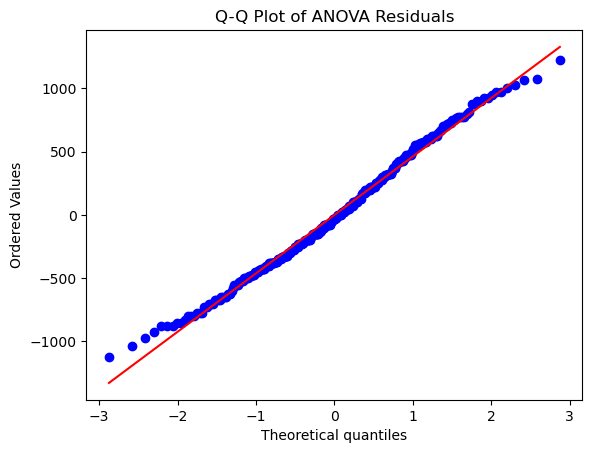

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()

### Normality of Residuals  

**Purpose:**  
The Shapiro‑Wilk test and Q‑Q plot assess whether the residuals from the ANOVA model are approximately normally distributed — another key assumption of ANOVA.  

**Hypotheses:**  
- **Null hypothesis (H₀):** Residuals follow a normal distribution.  
- **Alternative hypothesis (H₁):** Residuals deviate from normality.  

**Shapiro‑Wilk Test Results:**  
- Test Statistic (W) = 0.992  
- p‑value = 0.0512  

**Interpretation:**  
Because the p‑value is greater than 0.05, we fail to reject the null hypothesis. This suggests the residuals are approximately normal.  

**Q‑Q Plot:**  
The residuals align closely with the red reference line, visually confirming that they are roughly normally distributed.  

**Practical Implication:**  
The normality assumption for one‑way ANOVA is reasonably satisfied. Therefore, the ANOVA results can be considered valid with respect to residual normality.  

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


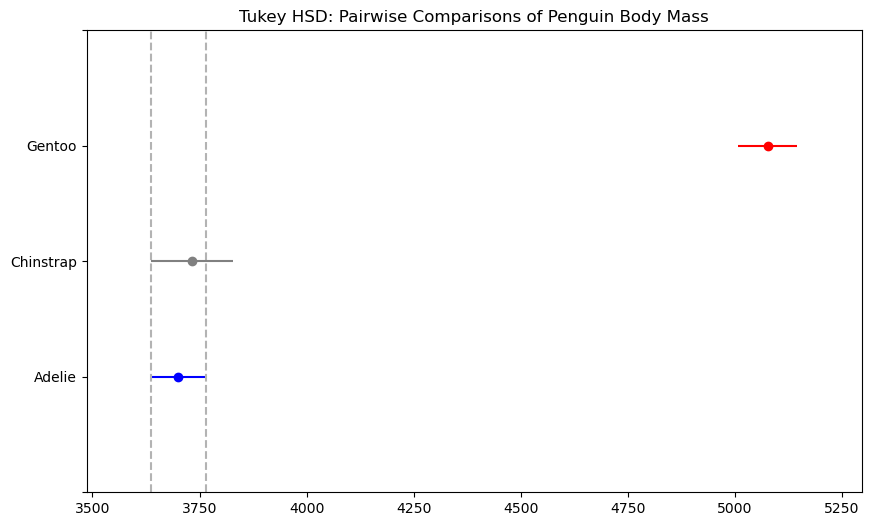

C:\Users\aysum\AppData\Local\Temp\ipykernel_9524\1185214326.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=penguins_clean, x='species', y='body_mass_g', capsize=0.1, join=False)


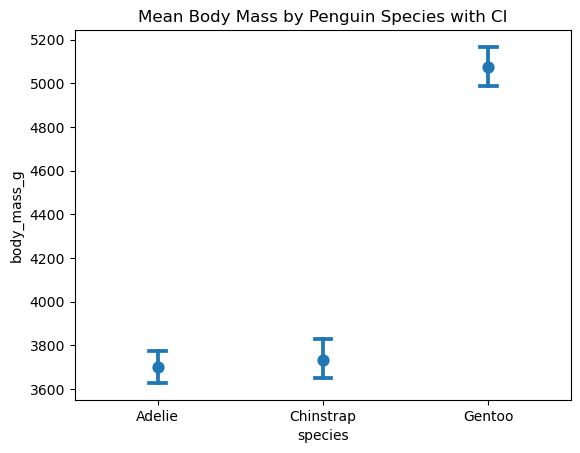

In [17]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns


tukey = pairwise_tukeyhsd(endog=penguins_clean['body_mass_g'],
                          groups=penguins_clean['species'],
                          alpha=0.05)


print(tukey.summary())


tukey.plot_simultaneous(comparison_name='Adelie')
plt.title("Tukey HSD: Pairwise Comparisons of Penguin Body Mass")
plt.show()

sns.pointplot(data=penguins_clean, x='species', y='body_mass_g', capsize=0.1, join=False)
plt.title("Mean Body Mass by Penguin Species with CI")
plt.show()

The overall ANOVA F‑test only tells us that some difference exists among species, but it doesn’t pinpoint where. That’s why we follow up with Tukey’s HSD test, which performs pairwise comparisons between species means.


### Tukey HSD Results – Interpretation  

**Key Findings:**  
- **Gentoo vs Adelie:** Significant difference in mean body mass (> 1000g).  
- **Gentoo vs Chinstrap:** Significant difference in mean body mass (> 1000g).  
- **Adelie vs Chinstrap:** No significant difference (≈ 32g).  

**Confidence Intervals:**  
- Gentoo differences are large and well above 1000g, making them both statistically and practically meaningful.  
- Adelie–Chinstrap difference is small (~32g) and confidence intervals overlap, showing no practical significance.  

**Visual Insights:**  
- Mean plots with confidence intervals reinforce the statistical results:  
  - Gentoo intervals are clearly separated from Adelie and Chinstrap → strong evidence of difference.  
  - Adelie and Chinstrap intervals overlap → no meaningful difference.  
